In [134]:
# Se importan las librerías necesarias.

import ast
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MultiLabelBinarizer
from skopt import BayesSearchCV

In [135]:
# Se carga el conjunto de datos.
churnData = pd.read_csv('ZumbaConsumerApp_Churn30D.csv')

In [136]:
# Se filtran las suscripciones anuales. Dado que estas tienen una duración alta, es una varaible que puede sesga el análisis del Churn a 30 días.
churnData = churnData[churnData['SUBSCRIPTION_TIER'] != 'Annual']

# Se eliminan columnas que no aportan información relevanta y aquellas que generan autocorrelación con otras columnas.
churnData = churnData.drop(columns = ['USER_ID', 'SUBSCRIPTION_ID', 'NEW_PAID_SUBSCRIPTION_DATE', 'PAID_SUBSCRIPTION_DURATION_DAYS', 'REGION_TYPE_LEVEL_1', 'REGION_TYPE_LEVEL_2', 'SUBSCRIPTION_AFFILIATE', 'MOTIVATING_FACTORS', 'CLASS_FORMAT_PREFERENCE', 'GENDER_IDENTITY', 'AGE'])

# Se eliminan filas con valores nulos en columnas categóricas relevantes, dado que el número de nulos de estas columnas es bajo.
churnData = churnData.dropna(subset = ['DEVICE_BRAND', 'DEVICE_OPERATING_SYSTEM', 'CLASS_INTENSITY_PREFERENCE', 'DANCE_LEVEL_PREFERENCE'])

In [137]:
# Las columnas de tipo 'lista' que tienen valores nulos son imputadas con listas vacías.
churnData['CLASS_INTENSITY_PREFERENCE'] = churnData['CLASS_INTENSITY_PREFERENCE'].fillna('[]')
churnData['MUSIC_PREFERENCE'] = churnData['MUSIC_PREFERENCE'].fillna('[]')

# A fin de implementar XGBoost de manera correcta, la columna FITNESS_GOAL_PREFERENCE es imputada con la categoría 'Unknown'.
churnData['FITNESS_GOAL_PREFERENCE'] = churnData['FITNESS_GOAL_PREFERENCE'].fillna('Unknown')

# Se definen las variables de tipo 'lista' que serán convertidas en variables dummy.
listColumns = ['CLASS_INTENSITY_PREFERENCE', 'MUSIC_PREFERENCE']

# Se convierten las columnas de tipo 'lista' en variables Dummy.
for col in listColumns:
    churnData[col] = churnData[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

mlb = MultiLabelBinarizer()
for col in listColumns:
    dummies = pd.DataFrame(mlb.fit_transform(churnData[col]), columns = [f'{col}_{cl}' for cl in mlb.classes_], index = churnData.index)
    churnData = pd.concat([churnData, dummies], axis = 1)

# Se eliminan las columnas originales de tipo 'lista'.
churnData = churnData.drop(columns = listColumns)

In [138]:
# A fin de utilizar XGBoost, se convierten las columnas categóricas al tipo 'category'.

categoricalColumns = [
    'SUBSCRIPTION_TIER',
    'SUBSCRIPTION_SOURCE',
    'SUBSCRIPTION_PROVIDER',
    'COUNTRY',
    'DANCE_LEVEL_PREFERENCE',
    'FITNESS_GOAL_PREFERENCE',
    'APP_VERSION',
    'DEVICE_OPERATING_SYSTEM',
    'DEVICE_MANUFACTURER',
    'DEVICE_BRAND',
    'DEVICE_MODEL'
    ]

churnData[categoricalColumns] = churnData[categoricalColumns].astype('category')

In [139]:
# Mejores variables para el modelo XGBoost tras un modelo de selección 'Backward Feature Elimination'.
variablesModelo = ['TRIAL_DURATION_DAYS', 'SUBSCRIPTION_TIER', 'SUBSCRIPTION_SOURCE', 'SUBSCRIPTION_PROVIDER', 'COUNTRY', 'CLASS_PER_WEEK_GOAL', 'DANCE_LEVEL_PREFERENCE', 'FITNESS_GOAL_PREFERENCE', 'APP_VERSION', 'DEVICE_OPERATING_SYSTEM', 'DEVICE_BRAND', 'APP_INSTALL_TO_PAID_SUBSCRIPTION_DAYS', 'NO_VIDEO_STARTED_30D', 'NO_VIDEO_WATCHED_30D', 'AVG_VIDEO_WATCHED_PERCENTAGE_30D', 'AVG_VIDEO_LENGTH_MIN_30D', 'CLASS_INTENSITY_PREFERENCE_High', 'CLASS_INTENSITY_PREFERENCE_Low', 'CLASS_INTENSITY_PREFERENCE_Medium', 'MUSIC_PREFERENCE_Afro Rhythms', 'MUSIC_PREFERENCE_Afrobeats', 'MUSIC_PREFERENCE_Alternative', 'MUSIC_PREFERENCE_Bachata', 'MUSIC_PREFERENCE_Belly Dance', 'MUSIC_PREFERENCE_Bellydance', 'MUSIC_PREFERENCE_Bhangra', 'MUSIC_PREFERENCE_Blues', 'MUSIC_PREFERENCE_Bollywood', 'MUSIC_PREFERENCE_Brazilian Rhythms', 'MUSIC_PREFERENCE_Broadway', 'MUSIC_PREFERENCE_Caribbean Rhythms', 'MUSIC_PREFERENCE_Chill Out', 'MUSIC_PREFERENCE_Country', 'MUSIC_PREFERENCE_Cumbia', 'MUSIC_PREFERENCE_Disco', 'MUSIC_PREFERENCE_Electronic', 'MUSIC_PREFERENCE_House', 'MUSIC_PREFERENCE_K-Pop', 'MUSIC_PREFERENCE_Merengue', 'MUSIC_PREFERENCE_Other', 'MUSIC_PREFERENCE_Pop', 'MUSIC_PREFERENCE_R&B', 'MUSIC_PREFERENCE_Reggae', 'MUSIC_PREFERENCE_Reggaeton', 'MUSIC_PREFERENCE_Rock', 'MUSIC_PREFERENCE_Salsa', 'MUSIC_PREFERENCE_Soca', 'MUSIC_PREFERENCE_Techno', 'MUSIC_PREFERENCE_World Rhythms']



# Se dividen los datos en conjuntos de entrenamiento y prueba.

xTotal = churnData[variablesModelo]
yTotal = churnData['PAID_SUBSCRIPTION_CHURN_30D']

xTrain, xTest, yTrain, yTest = train_test_split(xTotal, yTotal, test_size = 0.3, random_state = 0, stratify = yTotal)

In [140]:
# Se entrena el modelo XGBoost usando el conjunto de datos de entrenamiento.
xgbModel = xgb.XGBClassifier(enable_categorical = True, eval_metric = 'auc', random_state = 0)
xgbModel.fit(xTrain, yTrain)

# Se generan las predicciones del modelo.
yPred = xgbModel.predict(xTest)
yPredProb = xgbModel.predict_proba(xTest)[:, 1]

# Se evalua el desempeoño del modelo.
modelAUC = roc_auc_score(yTest, yPredProb)
modelAccuracy = accuracy_score(yTest, yPred)
modelPrecision = precision_score(yTest, yPred)
modelRecall = recall_score(yTest, yPred)
modelF1 = f1_score(yTest, yPred)

# Se imprimen las métricas de desempeño del modelo.
print(f'ROC AUC: {modelAUC:.4f}')
print(f'Accuracy: {modelAccuracy:.4f}')
print(f'Precision: {modelPrecision:.4f}')
print(f'Recall: {modelRecall:.4f}')
print(f'F1 Score: {modelF1:.4f}')

ROC AUC: 0.6380
Accuracy: 0.5985
Precision: 0.5610
Recall: 0.5342
F1 Score: 0.5473


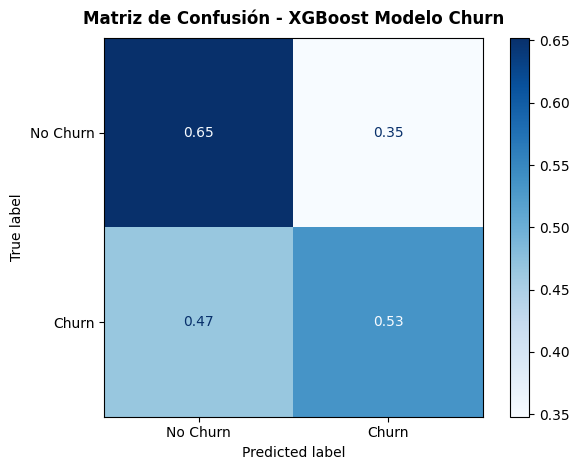

In [141]:
# Se crea la matriz de confusión.
ConfusionMatrixDisplay.from_predictions(yTest, yPred, display_labels = ['No Churn', 'Churn'],  cmap = 'Blues', normalize = 'true')
plt.title('Matriz de Confusión - XGBoost Modelo Churn', fontsize = 12, fontweight = 'bold', pad = 10)
plt.tight_layout()
plt.show()

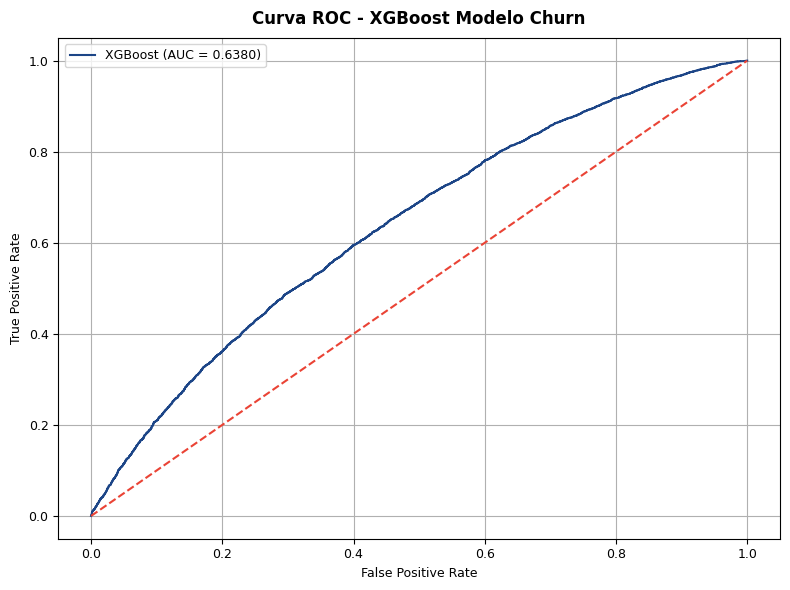

In [142]:
# Se crea la curva ROC del modelo entrenado

fpr, tpr, thresholds = roc_curve(yTest, yPredProb)

plt.figure(figsize = (8, 6))
plt.title('Curva ROC - XGBoost Modelo Churn', fontsize = 12, fontweight = 'bold', pad = 10)

plt.plot(fpr, tpr, label = f'XGBoost (AUC = {modelAUC:.4f})', color = '#1c4587')
plt.plot([0, 1], [0, 1], '--', color = '#ea4335')

plt.xlabel('False Positive Rate', fontsize = 9)
plt.ylabel('True Positive Rate', fontsize = 9)
plt.tick_params(axis = 'both', labelsize = 9)

plt.legend(fontsize = 9)
plt.grid(True)

plt.tight_layout()
plt.show()

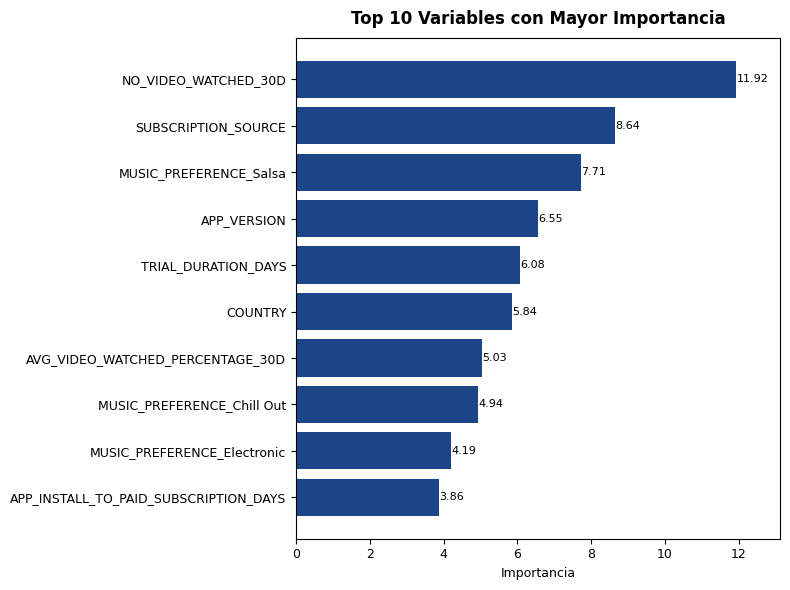

In [143]:
# Se crea un gráfico con las 10 variables más importantes del modelo XGBoost.

importance = xgbModel.get_booster().get_score(importance_type = 'gain')
importanceDF = pd.DataFrame({'Feature': list(importance.keys()), 'Importance': list(importance.values())}).sort_values(by = 'Importance', ascending = False).head(10)

plt.figure(figsize = (8, 6))
plt.title('Top 10 Variables con Mayor Importancia', fontsize = 12, fontweight = 'bold', pad = 10)

importanceBars = plt.barh(importanceDF['Feature'][::-1], importanceDF['Importance'][::-1], color = '#1c4587')

for bar in importanceBars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.2f}',
        va = 'center',
        fontsize = 8,
        color = 'black'
    )

plt.xlabel('Importancia', fontsize = 9)
plt.tick_params(axis = 'both', labelsize = 9)

plt.xlim(0, importanceDF['Importance'].max() * 1.1)

plt.tight_layout()
plt.show()

In [144]:
# Se implementa 'BayesSearchCV' para encontrar los mejores hiperparámetros del modelo XGBoost.

# Búsqueda amplia inicial.
searchSpace = {
    'n_estimators': [25, 50, 100, 250, 500, 750, 1000, 1500, 2000],
    'max_depth': [2, 3, 5, 7, 10, 12, 15, 20],
    'learning_rate': [0.005, 0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 3, 5, 7, 10],
    'reg_lambda': [0.05, 0.1, 0.3, 0.5, 1, 3, 5, 10, 20]
}

# Búsqueda más cerrada en el espacio de búsqueda de los mejores parámetros iniciales.
searchSpace = {
    'n_estimators': [300, 400, 500, 600, 700],
    'max_depth': [1, 2, 3, 4, 5],
    'learning_rate': [0.02, 0.025, 0.03, 0.035, 0.04],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.65, 0.7, 0.75, 0.8],
    'min_child_weight': [5, 6, 7, 8, 9],
    'reg_lambda': [8, 9, 10, 11, 12]
}

bayesSearch = BayesSearchCV(
    estimator = xgbModel,
    search_spaces = searchSpace,
    n_iter = 100,
    cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 0),
    scoring = 'roc_auc',
    random_state = 0,
    n_jobs = -1
)

bayesSearch.fit(xTrain, yTrain)

BayesSearchCV(cv=StratifiedKFold(n_splits=5, random_state=0, shuffle=True),
              estimator=XGBClassifier(base_score=None, booster=None,
                                      callbacks=None, colsample_bylevel=None,
                                      colsample_bynode=None,
                                      colsample_bytree=None, device=None,
                                      early_stopping_rounds=None,
                                      enable_categorical=True,
                                      eval_metric='auc', feature_types=None,
                                      feature_weights=None, gamma=None,
                                      grow_polic...
                                      n_jobs=None, num_parallel_tree=None, ...),
              n_iter=100, n_jobs=-1, random_state=0, scoring='roc_auc',
              search_spaces={'colsample_bytree': [0.6, 0.65, 0.7, 0.75, 0.8],
                             'learning_rate': [0.02, 0.025, 0.03, 0.035, 0.04],
                             'max_depth': [1, 2, 3, 4, 5],
                             'min_child_weight': [5, 6, 7, 8, 9],
                             'n_estimators': [300, 400, 500, 600, 700],
                             'reg_lambda': [8, 9, 10, 11, 12],
                             'subsample': [0.5, 0.6, 0.7, 0.8, 0.9]})

In [153]:
print(f'Mejores hiperparámetros encontrados: {bayesSearch.best_params_}')

Mejores hiperparámetros encontrados: OrderedDict({'colsample_bytree': 0.65, 'learning_rate': 0.02, 'max_depth': 5, 'min_child_weight': 9, 'n_estimators': 600, 'reg_lambda': 8, 'subsample': 0.7})


In [145]:
# Reentrenar el mejor modelo en todo el conjunto de entrenamiento
bestModel = bayesSearch.best_estimator_
bestModel.fit(xTrain, yTrain)

# Se generan las predicciones del modelo.
yPred = bestModel.predict(xTest)
yPredProb = bestModel.predict_proba(xTest)[:, 1]

# Se evalua el desempeño del modelo.
modelAccuracy = accuracy_score(yTest, yPred)
modelPrecision = precision_score(yTest, yPred)
modelRecall = recall_score(yTest, yPred)
modelF1 = f1_score(yTest, yPred)
modelAUC = roc_auc_score(yTest, yPredProb)

# Se imprimen las métricas de desempeño del modelo.
print(f'ROC AUC: {modelAUC:.4f}')
print(f'Accuracy: {modelAccuracy:.4f}')
print(f'Precision: {modelPrecision:.4f}')
print(f'Recall: {modelRecall:.4f}')
print(f'F1 Score: {modelF1:.4f}')

ROC AUC: 0.6599
Accuracy: 0.6168
Precision: 0.5868
Recall: 0.5289
F1 Score: 0.5564


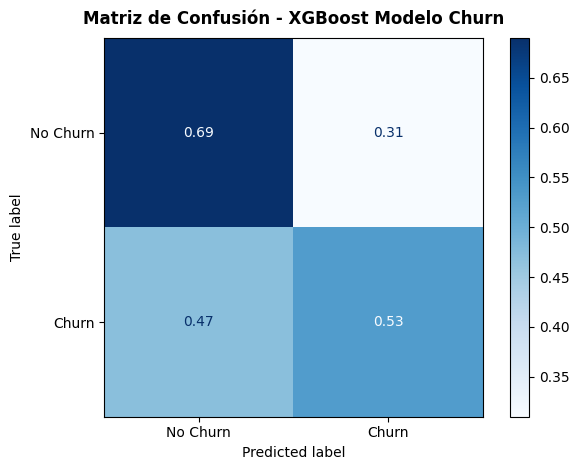

In [146]:
# Se crea la matriz de confusión.
ConfusionMatrixDisplay.from_predictions(yTest, yPred, display_labels = ['No Churn', 'Churn'],  cmap = 'Blues', normalize = 'true')
plt.title('Matriz de Confusión - XGBoost Modelo Churn', fontsize = 12, fontweight = 'bold', pad = 10)
plt.tight_layout()
plt.show()

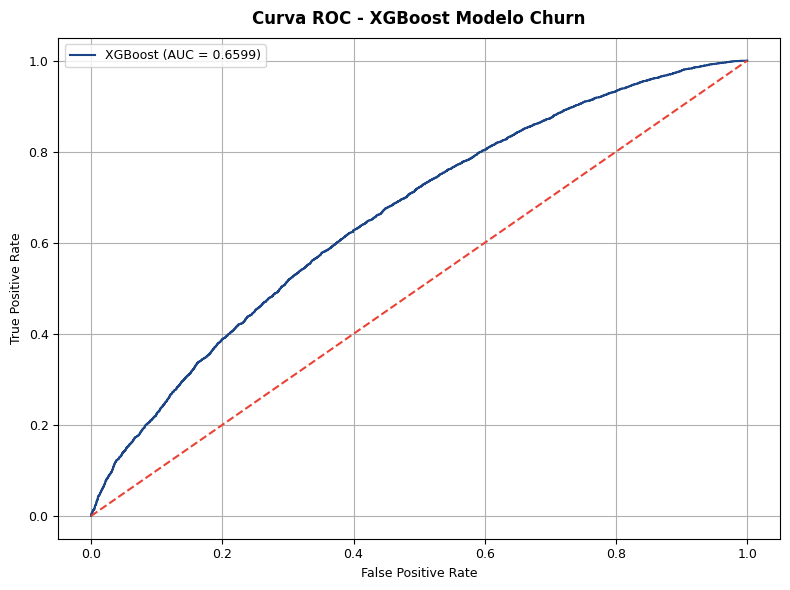

In [147]:
# Se crea la curva ROC del modelo entrenado

fpr, tpr, thresholds = roc_curve(yTest, yPredProb)

plt.figure(figsize = (8, 6))
plt.title('Curva ROC - XGBoost Modelo Churn', fontsize = 12, fontweight = 'bold', pad = 10)

plt.plot(fpr, tpr, label = f'XGBoost (AUC = {modelAUC:.4f})', color = '#1c4587')
plt.plot([0, 1], [0, 1], '--', color = '#ea4335')

plt.xlabel('False Positive Rate', fontsize = 9)
plt.ylabel('True Positive Rate', fontsize = 9)
plt.tick_params(axis = 'both', labelsize = 9)

plt.legend(fontsize = 9)
plt.grid(True)

plt.tight_layout()
plt.show()

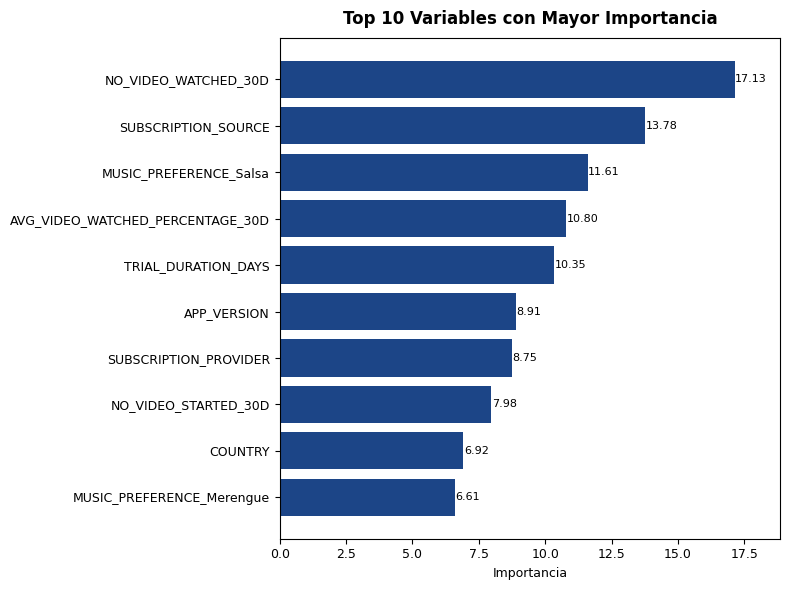

In [148]:
# Se crea un gráfico con las 10 variables más importantes del modelo XGBoost.

importance = bestModel.get_booster().get_score(importance_type = 'gain')
importanceDF = pd.DataFrame({'Feature': list(importance.keys()), 'Importance': list(importance.values())}).sort_values(by = 'Importance', ascending = False).head(10)

plt.figure(figsize = (8, 6))
plt.title('Top 10 Variables con Mayor Importancia', fontsize = 12, fontweight = 'bold', pad = 10)

importanceBars = plt.barh(importanceDF['Feature'][::-1], importanceDF['Importance'][::-1], color = '#1c4587')

for bar in importanceBars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.2f}',
        va = 'center',
        fontsize = 8,
        color = 'black'
    )

plt.xlabel('Importancia', fontsize = 9)
plt.tick_params(axis = 'both', labelsize = 9)

plt.xlim(0, importanceDF['Importance'].max() * 1.1)

plt.tight_layout()
plt.show()